In [1]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, Rabc, Quad, ChemShift, AntiShift
import sympy as sym
B0 = 14.1 #magnetic field used
w0 = 192.55 #input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


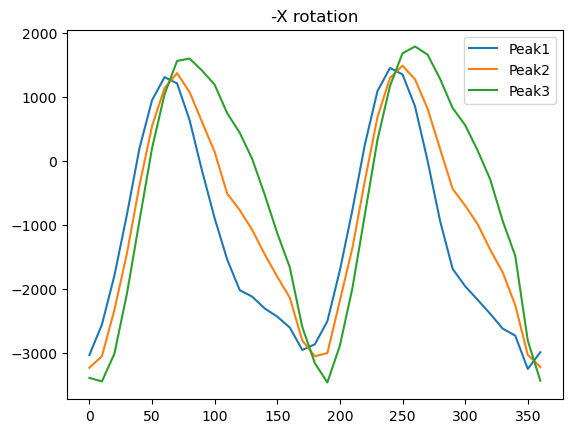

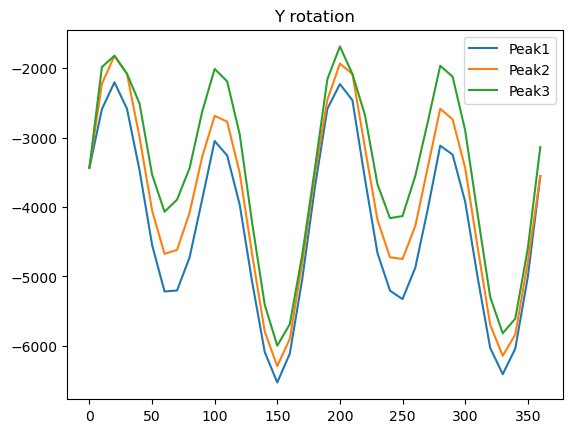

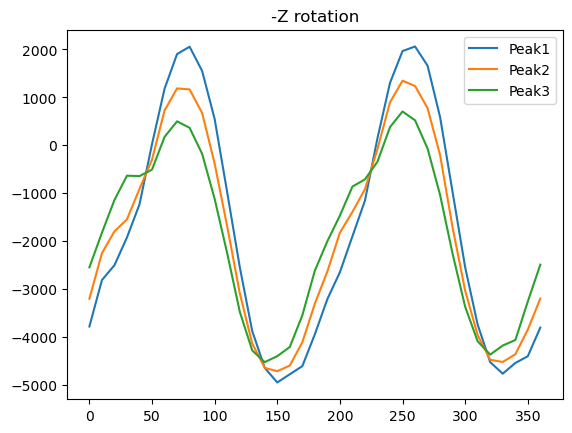

In [2]:
titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3

    
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Z_Rot', skiprows=[1])
for i in range(3):

    df[i].Cluster2Peak0 = df[i].Cluster2Peak0*w0
    df[i].Cluster2Peak1 = df[i].Cluster2Peak1*w0
    df[i].Cluster2Peak2 = df[i].Cluster2Peak2*w0

    # print(df[i].Cluster1Peak1)
    plt.plot(df[i].Angle, df[i].Cluster2Peak0, label = 'Peak1')
    plt.plot(df[i].Angle, df[i].Cluster2Peak1, label = 'Peak2')
    plt.plot(df[i].Angle, df[i].Cluster2Peak2, label = 'Peak3')
    plt.title(titles[i])
    plt.legend()
    plt.show()

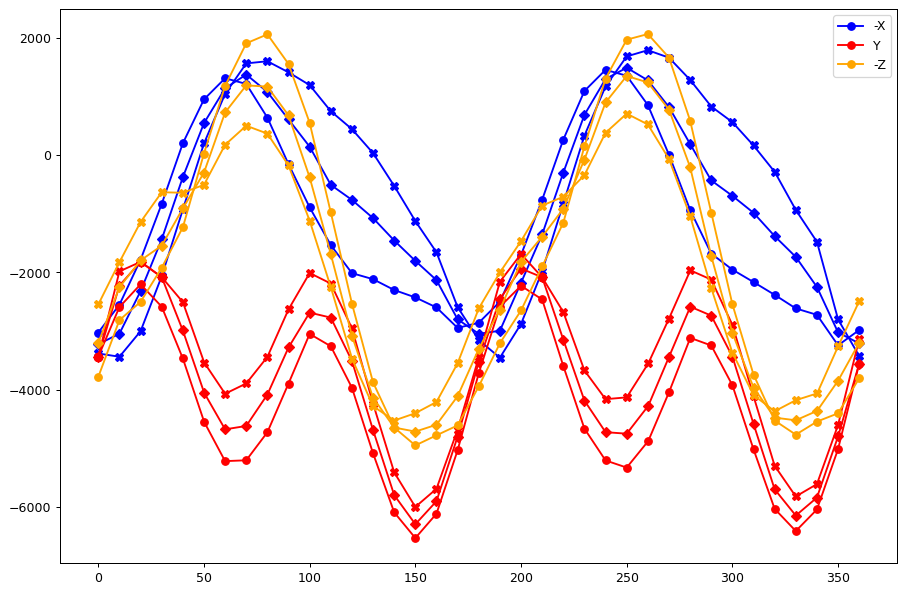

In [3]:
plt.figure(figsize = (12,8), dpi = 90)

plt.plot(df[0].Angle, df[0].Cluster2Peak0,'-bo' ,label = '-X')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,'-bD')
plt.plot(df[0].Angle, df[0].Cluster2Peak2, '-bX')

plt.plot(df[1].Angle, df[1].Cluster2Peak0,'-ro' ,label = 'Y')
plt.plot(df[1].Angle, df[1].Cluster2Peak1,'-rD')
plt.plot(df[1].Angle, df[1].Cluster2Peak2, '-rX')

plt.plot(df[2].Angle, df[2].Cluster2Peak0, linestyle='-', marker='o', color = 'orange',label = '-Z')
plt.plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='-', marker='D', color = 'orange')
plt.plot(df[2].Angle, df[2].Cluster2Peak2, linestyle='-', marker='X', color = 'orange')

plt.legend()

In [4]:
freq_sum = [0]*3
freq_diff = [0]*3
for i in range(3):

    freq_sum[i] = df[i].Cluster2Peak0 + df[i].Cluster2Peak1 + df[i].Cluster2Peak2
    freq_diff[i] = df[i].Cluster2Peak0 - df[i].Cluster2Peak2

    # print(freq_sum[i])
# plt.plot(df[i].Angle, freq_sum)
# plt.show()
# plt.plot(df[i].Angle, freq_diff)

┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1   -0.0359  -3.6e-05   -0.0359   0.00026 │
│ b │   -0.0359         1   0.00017   -0.0511  0.000132 │
│ c │  -3.6e-05   0.00017         1  0.000152 -0.000347 │
│ d │   -0.0359   -0.0511  0.000152         1 -0.000304 │
│ e │   0.00026  0.000132 -0.000347 -0.000304         1 │
└───┴───────────────────────────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.454e+08 (chi2/ndof = 7668307.9)│              Nfcn = 130              │
│ EDM = 6.73e-15 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid

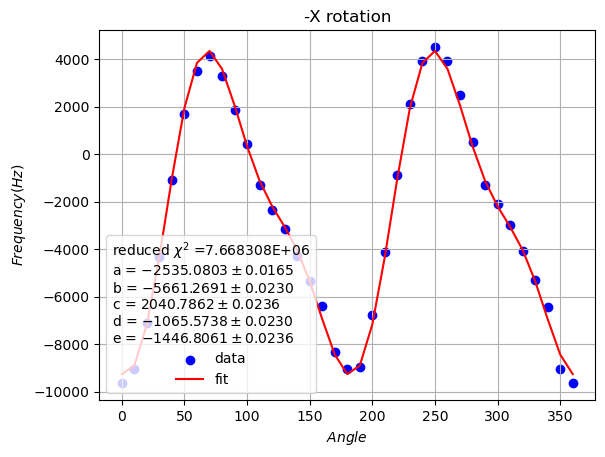

a = -2535.080283721655
b = -5661.269134238255
c = 2040.7861741172746
d = -1065.5737981751306
e = -1446.8060951984894
┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1   -0.0356  0.000415   -0.0361 -0.000373 │
│ b │   -0.0356         1 -0.000273   -0.0512  0.000608 │
│ c │  0.000415 -0.000273         1  1.42e-06  0.000131 │
│ d │   -0.0361   -0.0512  1.42e-06         1 -0.000509 │
│ e │ -0.000373  0.000608  0.000131 -0.000509         1 │
└───┴───────────────────────────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.681e+08 (chi2/ndof = 5252706.7)│              Nfcn = 122              │
│ EDM = 8.67e-10 (Goal: 0.0002)    │               

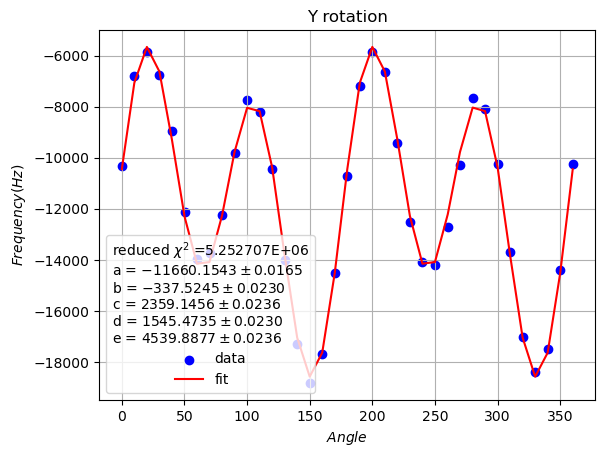

a = -11660.154313043346
b = -337.5245263448118
c = 2359.145611656144
d = 1545.4734787343814
e = 4539.887692354333
┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1    -0.036 -3.44e-05   -0.0358   7.5e-05 │
│ b │    -0.036         1   6.9e-05   -0.0516   -0.0002 │
│ c │ -3.44e-05   6.9e-05         1  -0.00012  0.000105 │
│ d │   -0.0358   -0.0516  -0.00012         1  0.000547 │
│ e │   7.5e-05   -0.0002  0.000105  0.000547         1 │
└───┴───────────────────────────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.878e+08 (chi2/ndof = 15244809.8)│              Nfcn = 129              │
│ EDM = 1.35e-14 (Goal: 0.0002)    │                 

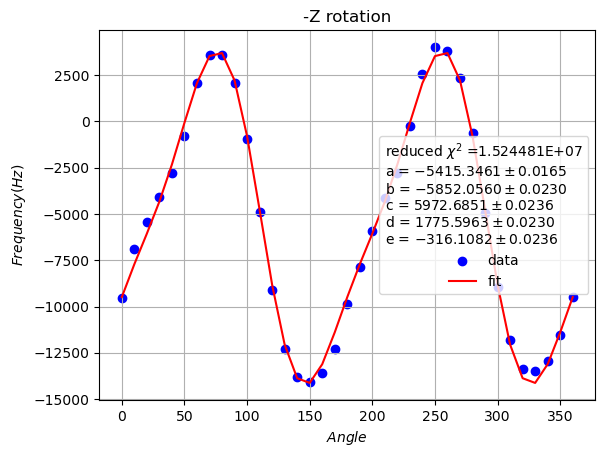

a = -5415.346032044893
b = -5852.05600235503
c = 5972.685194614684
d = 1775.5963188313542
e = -316.1081664465568


In [5]:
m_s = [0]*3
corr_mat = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, freq_sum[i], 0.1,fourier5)
    
    m_s[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_s[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi^2$ ={(m_s[i].fval / (len(df[i].Angle) - m_s[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_s[i].parameters, m_s[i].values, m_s[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_s[i].covariance.correlation())
    print(corr_mat)
    print(m_s[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].Angle, freq_sum[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier5(df[i].Angle, *m_s[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_s[i].parameters, m_s[i].values):
        print(f"{key} = {value}")

┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0378 -3.04e-05 │
│ b │   -0.0378         1  0.000178 │
│ c │ -3.04e-05  0.000178         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.404e+07 (chi2/ndof = 1295314.1)│              Nfcn = 93               │
│ EDM = 5.95e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼────────

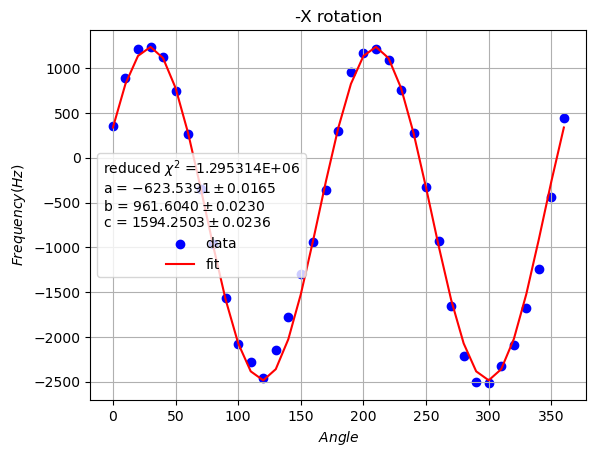

a = -623.5389568499266
b = 961.6041480505326
c = 1594.2502474994772
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0375  0.000415 │
│ b │   -0.0375         1 -0.000273 │
│ c │  0.000415 -0.000273         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.063e+07 (chi2/ndof = 1194991.8)│              Nfcn = 93               │
│ EDM = 5.99e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below

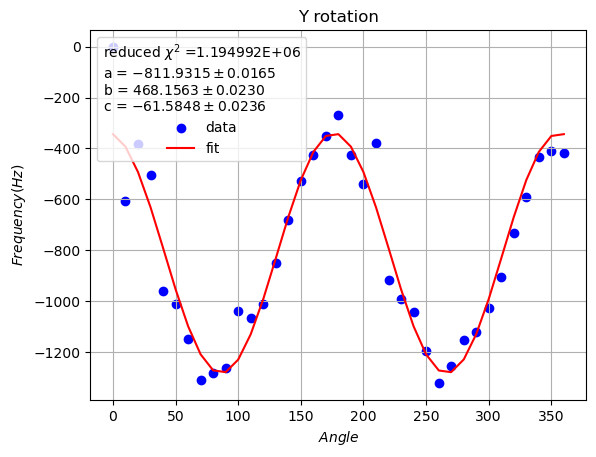

a = -811.931486648424
b = 468.156282487009
c = -61.584783775520116
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0379 -3.87e-05 │
│ b │   -0.0379         1  6.29e-05 │
│ c │ -3.87e-05  6.29e-05         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.596e+08 (chi2/ndof = 4693463.1)│              Nfcn = 80               │
│ EDM = 7.33e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below 

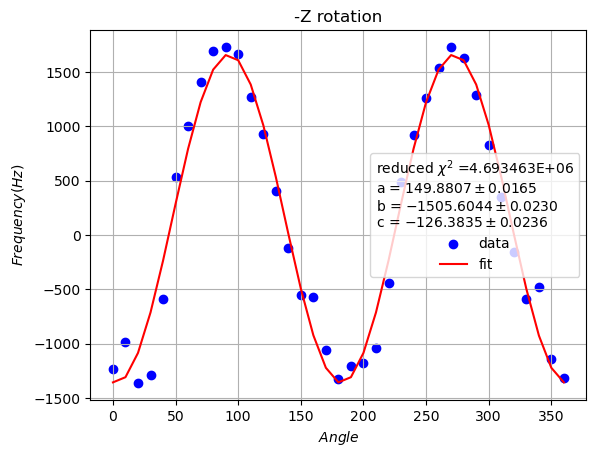

a = 149.88066472818548
b = -1505.6043228501217
c = -126.38358709418418


In [6]:
m_d = [0]*3
corr_mat = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, freq_diff[i], 0.1,fourier3)
    
    m_d[i] = Minuit(least_squares, a = 1, b = 1, c = 0).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_d[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi^2$ ={(m_d[i].fval / (len(df[i].Angle) - m_d[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_d[i].parameters, m_d[i].values, m_d[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_d[i].covariance.correlation())
    print(corr_mat)
    print(m_d[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].Angle, freq_diff[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier3(df[i].Angle, *m_d[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(text[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_d[i].parameters, m_d[i].values):
        print(f"{key} = {value}")

**Find HQ Tensor**

In [7]:
a_s = [0]*3; a_d = [0]*3
b_s = [0]*3; b_d = [0]*3
c_s = [0]*3; c_d = [0]*3
d_s = [0]*3
e_s = [0]*3

par_s = [a_s, b_s, c_s, d_s, e_s]
par_d = [a_d, b_d, c_d]

for i in range(0,3):
    for k in range(len(par_s)):
        par_s[k][i] = m_s[i].values[k]
    for j in range(len(par_d)):
        par_d[j][i] = m_d[i].values[j]
# Quadrupolar coefficients
A_Q = [0]*3
B_Q = [0]*3
C_Q = [0]*3

A_HQ1 = [0]*3
B_HQ1 = [0]*3
X = [0]*3
# https://stackoverflow.com/questions/36354807/solving-linear-equations-w-three-variables-using-numpy

for i in range(0,3):
    A_HQ1[i] = np.array([[1/2, 1/2], [1/2, -1/2]])
    B_HQ1[i] = np.array([a_d[i], b_d[i]])
    X[i] = np.linalg.inv(A_HQ1[i]).dot(B_HQ1[i])

gzz_q1 = X[0][0]
gyy_q1= X[0][1]
gyz_q = -c_d[0]

gzz_q2 = X[1][0]
gxx_q2 = X[1][1]
gxz_q = c_d[1]

gxx_q3 = X[2][0]
gyy_q3 = X[2][1]
gxy_q = -c_d[2]

gxx_q = np.mean([gxx_q2, gxx_q3])
gyy_q = np.mean([gyy_q1, gyy_q3])
gzz_q = np.mean([gzz_q1, gzz_q2])




QXG_f = np.zeros((3, 3))                                #Tensor from fitting
QXG_f[0,0]=gxx_q; QXG_f[0,1]=gxy_q; QXG_f[0,2]=gxz_q;
QXG_f[1,0]=gxy_q; QXG_f[1,1]=gyy_q; QXG_f[1,2]=gyz_q;
QXG_f[2,0]=gxz_q; QXG_f[2,1]=gyz_q; QXG_f[2,2]=gzz_q;

   #Plot to check that difference frequency is mostly HQ1
#    plt.plot(df[i].angle, HQ1[i], label = 'HQ1')
#    plt.plot(df[i].angle, df[i].freq_diff, label = 'diff frequency')
#    plt.legend()
#    plt.show()


print('Calculated Quad Tensor:\n',QXG_f)

Calculated Quad Tensor:
 [[-1317.90571363   126.38358709   -61.58478378]
 [  126.38358709    35.17094134 -1594.2502475 ]
 [  -61.58478378 -1594.2502475     -2.85500648]]


In [16]:
# A = np.array([gzz_q + gyy_q, gzz_q + gxx_q, gxx_q + gyy_q])*1/2
# B = np.array([gzz_q - gyy_q, gzz_q - gxx_q, gxx_q - gyy_q ])*1/2
# C = np.array([-gyz_q, gxz_q, -gxy_q])

# HQ1= [0]*3

# for i in range(3):
#    HQ1[i] = a_d[i] + b_d[i]*np.cos(2*df[i].Angle*np.pi/180.) + c_d[i]*np.cos(2*df[i].Angle*np.pi/180.) 

#    #Plot to check that difference frequency is mostly HQ1
#    plt.plot(df[i].Angle, HQ1[i], label = 'HQ1')
#    plt.plot(df[i].Angle, freq_diff[i], label = 'diff frequency')
#    plt.legend()
#    plt.show()

**Find HQ1 and HQ2**

In [8]:
HQ1_freq_3212 = [0]*3
HQ1_freq_1212 = [0]*3
HQ1_freq_1232 = [0]*3


HQ2_freq_3212 = [0]*3
HQ2_freq_1212 = [0]*3
HQ2_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].Angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)

            
    HQ1 = 1/(2*Ispin*(2*Ispin-1))*R20Q
    HQ2a= (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m2Q*R2p2Q)/wX                         
    HQ2b = (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m1Q*R2p1Q)/wX


    HQ1_freq_3212[i] = 6*(np.real(HQ1))               # 3/2 <-> 1/2
    HQ1_freq_1212[i] = 0*(np.real(HQ1))               # 1/2 <-> -1/2
    HQ1_freq_1232[i] = -6*(np.real(HQ1))              #-1/2   <-> -3/2       
    
    HQ2_freq_3212[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       # 3/2 <-> 1/2
    HQ2_freq_1212[i] = 6*np.real(HQ2a) + 12*np.real(HQ2b)        # 1/2 <-> -1/2
    HQ2_freq_1232[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       #-1/2   <-> -3/2                                                                          


# len(HQ_freq_3212[0])
# len(df[0].freq_3212)

# print(HQ_freq_3212[0])

# HQ1_3212 = 1/4*(gzz_q + gxx_q + (gzz_q - gxx_q)*np.cos(2*df[i].angle*np.pi/180.) + 2*gxz_q*np.cos(2*df[i].angle*np.pi/180.))
# HQ1_1212 = 0
# HQ1_1232 = -1/4*(gzz_q + gxx_q + (gzz_q - gxx_q)*np.cos(2*df[i].angle*np.pi/180.) + 2*gxz_q*np.cos(2*df[i].angle*np.pi/180.))

**Verify Tensor Components from HQ2**

In [9]:
Dx = (-21/16*(gzz_q - gyy_q)**2 + 21/4*gyz_q**2)/(72*wX)
Ex = 21/4*(gzz_q - gyy_q)*gyz_q/(72*wX)

Dy = (-21/16*(gzz_q - gxx_q)**2 + 21/4*gxz_q**2)/(72*wX)
Ey = (-21/4*gxz_q*(gzz_q - gxx_q))/(72*wX)

Dz = (-21/16*(gxx_q - gyy_q)**2 + 21/4*gxy_q**2)/(72*wX)
Ez = (21/4*gxy_q*(gxx_q - gyy_q))/(72*wX)

table = [['Dx', d_s[0], Dx],  ['Ex', e_s[0], Ex],['Dy', d_s[1], Dy],  ['Ey', e_s[1], Ey], ['Dz', d_s[2], Dz],  ['Ez', e_s[2], Ez]]
print(tabulate(table, headers=['Coefficient','Coefficients from fit', 'Calculated coefficients']))

Coefficient      Coefficients from fit    Calculated coefficients
-------------  -----------------------  -------------------------
Dx                           -1065.57                 0.000962353
Ex                           -1446.81                 2.29572e-05
Dy                            1545.47                -0.000162286
Ey                            4539.89                 3.0669e-05
Dz                            1775.6                 -0.000167279
Ez                            -316.108               -6.47584e-05


**Find CSA Tensor**

┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0378 -3.05e-05 │
│ b │   -0.0378         1  0.000178 │
│ c │ -3.05e-05  0.000178         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.164e+07 (chi2/ndof = 1812951.4)│              Nfcn = 93               │
│ EDM = 3.07e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼────────

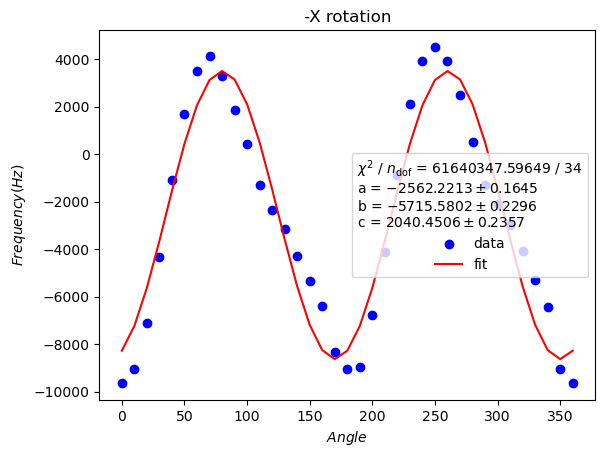

a = -2562.221325075511
b = -5715.580368593132
c = 2040.4505610492563
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0375  0.000415 │
│ b │   -0.0375         1 -0.000273 │
│ c │  0.000415 -0.000273         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.18e+08 (chi2/ndof = 12292885.0)│              Nfcn = 86               │
│ EDM = 3.27e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Belo

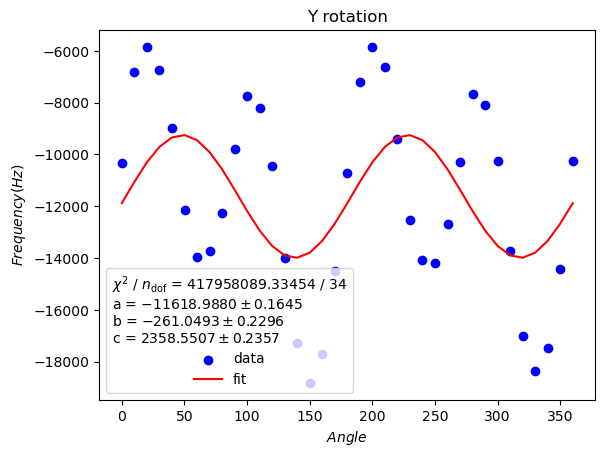

a = -11618.989544604625
b = -261.0491947120269
c = 2358.5503682401813
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0379 -3.87e-05 │
│ b │   -0.0379         1  6.29e-05 │
│ c │ -3.87e-05  6.29e-05         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.637e+07 (chi2/ndof = 1952101.6)│              Nfcn = 93               │
│ EDM = 1.4e-17 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Bel

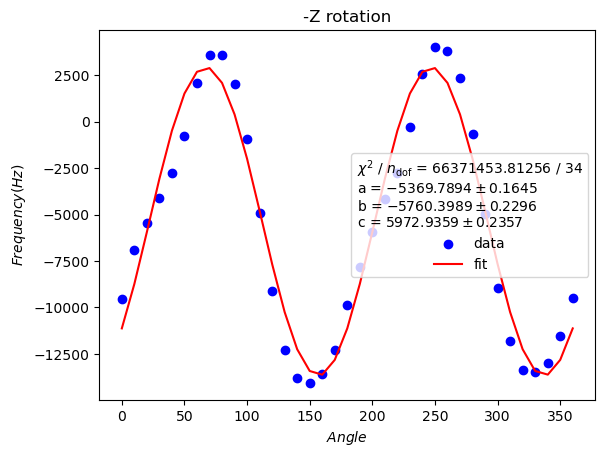

a = -5369.789462438069
b = -5760.398711411087
c = 5972.93615134211


In [10]:
HQ2_freq_sum = [0]*3
csa = [0]*3
# y_csa[0] = np.subtract(f_s[0], HQ2[0]) 
# print(f_s[0], HQ2[0], y_csa[0])
# 
for i in range(3):
    HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    csa[i] = freq_sum[i] - HQ2_freq_sum[i]


# HQ2_freq_sum = [0]*3
m_csa = [0]*3
# y_csa = [0]*3
# y_csa[0] = np.subtract(f_s[0], HQ2[0]) 
# print(f_s[0], HQ2[0], y_csa[0])
# 
for i in range(0,3):
    # HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    # y_csa[i] = np.subtract(df[i].freq_sum, HQ2_freq_sum[i])    
    # y_csa[i] = np.subtract(df[i].freq_sum, HQ2[i]) 
    least_squares = LeastSquares(df[i].Angle, csa[i], 1,fourier3)
    
    m_csa[i] = Minuit(least_squares, a = -1, b = -1, c= -1)
    # m[i] = m[i].scan(ncall = 50)

    m_csa[i].migrad()  # finds minimum of least_squares function
    m_csa[i].hesse()   # accurately computes uncertainties
    fit_info = [
        f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m_csa[i].fval:.5f} / {len(df[i].Angle) - m_csa[i].nfit}",
    ]
    # print(fit_info)
    

    for p, v, e in zip(m_csa[i].parameters, m_csa[i].values, m_csa[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_csa[i].covariance.correlation())
    print(corr_mat)
    print(m_csa[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].Angle, csa[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier3(df[i].Angle, *m_csa[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()
    
    for key, value in zip(m_csa[i].parameters, m_csa[i].values):
        print(f"{key} = {value}")

a_csa = [0]*3; 
b_csa = [0]*3; 
c_csa = [0]*3; 

par_csa = [a_csa, b_csa, c_csa]

for i in range(0,3):
    for k in range(len(par_csa)):
        par_csa[k][i] = m_csa[i].values[k]


In [11]:
A= [0]*3
B = [0]*3
C = [0]*3
A_HCSA1 = [0]*3
B_HCSA1 = [0]*3
X = [0]*3


for i in range(0,3):

    A_HCSA1[i] = np.array([[3/2, 3/2], [3/2, -3/2]])
    B_HCSA1[i] = np.array([a_csa[i], b_csa[i]])
    X[i] = np.linalg.inv(A_HCSA1[i]).dot(B_HCSA1[i])
    

gzz_csa1 = X[0][0]
gyy_csa1= X[0][1]
gyz_csa = -c_csa[0]/3

gzz_csa2 = X[1][0]
gxx_csa2 = X[1][1]
gxz_csa = c_csa[1]/3

gxx_csa3 = X[2][0]
gyy_csa3 = X[2][1]
gxy_csa = -c_csa[2]/3

gxx_csa = np.mean([gxx_csa2, gxx_csa3])
gyy_csa = np.mean([gyy_csa1, gyy_csa3])
gzz_csa = np.mean([gzz_csa1, gzz_csa2])




CsaQXG_f = np.zeros((3, 3))                                #Tensor from fitting
CsaQXG_f[0,0]=gxx_csa; CsaQXG_f[0,1]=gxy_csa; CsaQXG_f[0,2]=gxz_csa;
CsaQXG_f[1,0]=gxy_csa; CsaQXG_f[1,1]=gyy_csa; CsaQXG_f[1,2]=gyz_csa;
CsaQXG_f[2,0]=gxz_csa; CsaQXG_f[2,1]=gyz_csa; CsaQXG_f[2,2]=gzz_csa;



print('Calculated Quad Tensor:\n',CsaQXG_f)


print(tabulate([['gxx_q',gxx_q], ['gyy_q',gyy_q], ['gzz_q',gzz_q], ['gxy_q',gxy_q], ['gyz_q',gyz_q], ['gxz_q',gxz_q],['gxx_csa',gxx_csa], ['gyy_csa',gyy_csa], ['gzz_csa',gzz_csa], ['gxy_csa',gxy_csa], ['gyz_csa',gyz_csa], ['gxz_csa',gxz_csa]]))

Calculated Quad Tensor:
 [[-3748.02142062 -1990.97871711   786.18345608]
 [-1990.97871711   590.66138208  -680.15018702]
 [  786.18345608  -680.15018702 -3359.64007216]]
-------  -----------
gxx_q    -1317.91
gyy_q       35.1709
gzz_q       -2.85501
gxy_q      126.384
gyz_q    -1594.25
gxz_q      -61.5848
gxx_csa  -3748.02
gyy_csa    590.661
gzz_csa  -3359.64
gxy_csa  -1990.98
gyz_csa   -680.15
gxz_csa    786.183
-------  -----------


In [12]:
#****** Input Vaue****************
#coupling values for NAV (taken from paper https://pubmed.ncbi.nlm.nih.gov/22027340/)


#for CSA
Siso_fit = (gxx_csa + gyy_csa + gzz_csa)/3
Siso_ppm_fit = Siso_fit/w0
delta_fit = gzz_csa/w0 - Siso_ppm_fit
eta_fit = (gxx_csa - gyy_csa)/w0/delta_fit

#for Quadrupolar
CQ_fit = gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
Qeta_fit = (gxx_q - gyy_q)/gzz_q

table = [['Siso (ppm)',Siso_ppm_fit ],['delta (ppm)', delta_fit],  ['eta', eta_fit],  ['CQ (MHz)', CQ_fit], ['Qeta', Qeta_fit ]]
print(tabulate(table, headers=['Qauntity', 'Fit Value']))

Qauntity       Fit Value
-----------  -----------
Siso (ppm)   -11.2819
delta (ppm)   -6.16623
eta            3.65422
CQ (MHz)      -1.713e-05
Qeta         473.931
